# Projeto 6 — Amostragem de Redes Complexas

**Objetivo:** Comparar, modelar e estender métodos de amostragem de redes complexas,
avaliando o quanto preservam propriedades estruturais da rede original.

---

## 1. Introdução

Redes complexas são representações de sistemas interconectados presentes em diversas áreas:
redes sociais, biológicas, de infraestrutura e informação. Em muitos cenários práticos, a rede
completa é grande demais para ser analisada diretamente, tornando necessário o uso de **métodos
de amostragem**.

No entanto, a amostragem introduz **viés estrutural**: propriedades como distribuição de grau,
coeficiente de clustering e caminhos mínimos podem ser distorcidas. A escolha do método de
amostragem e da fração amostral impacta diretamente a qualidade das análises downstream.

### Hipótese central

> **Não existe um sampler universalmente ótimo.** O melhor método depende da topologia da rede
> e do objetivo de preservação estrutural.

---

## 2. Objetivos

### Geral
Avaliar sistematicamente métodos de amostragem de redes complexas e propor extensões.

### Específicos
1. **Nível 1:** Benchmark multicritério de 6 métodos clássicos de amostragem.
2. **Nível 2:** Meta-modelo preditivo para recomendar o melhor sampler.
3. **Nível 3:** Contribuições originais:
   - C1: Goal-Oriented Adaptive Sampling (GOAS)
   - C2: Structural Preservation Pareto Frontier
   - C3: Self-Supervised Graph Sampling via RL

## 3. Metodologia

### 3.1 Redes Sintéticas
- **Erdős-Rényi (ER):** modelo aleatório clássico
- **Barabási-Albert (BA):** redes livre de escala
- **Watts-Strogatz (WS):** redes de mundo pequeno
- Tamanhos: 1000 e 5000 nós

### 3.2 Métodos de Amostragem
- Random Node, Random Edge, Snowball, Random Walk
- Preferential Random Walk, Metropolis-Hastings RW
- GOAS (contribuição original)

### 3.3 Métricas Topológicas
- Distribuições: grau, clustering, betweenness, eigenvector, closeness, k-core
- Globais: densidade, grau médio, transitividade, assortatividade, etc.

### 3.4 Structural Preservation Score (SPS)
Métrica composta que combina divergências JS e erros relativos.

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from src.utils import load_config, results_path

config = load_config('../configs/default.yaml')
print('Configuração carregada.')

Configuração carregada.


## 4. Nível 1: Benchmark Multicritério

Resultados da comparação sistemática dos métodos de amostragem.

In [2]:
# Carregar resultados do Nível 1
try:
    df_dist = pd.read_csv(results_path(config, 'raw', 'level1_distribution_distances.csv'))
    df_global = pd.read_csv(results_path(config, 'raw', 'level1_global_errors.csv'))
    print(f'Resultados carregados: {len(df_dist)} linhas de distâncias')
    display(df_dist.groupby('sampler')['SPS'].describe().round(4))
except FileNotFoundError:
    print('Resultados do Nível 1 não encontrados.')
    print('Execute: python scripts/run_level1_benchmark.py --config configs/default.yaml')

Resultados carregados: 5400 linhas de distâncias


,count,mean,std,min,25%,50%,75%,max
sampler,,,,,,,,
metropolis_hastings_rw,900.0,0.3813,0.1938,0.0600,0.2164,0.3601,0.4997,1.5482
preferential_random_walk,900.0,0.4716,0.2441,0.1210,0.3045,0.4386,0.5943,1.6401
random_edge,900.0,0.4303,0.1844,0.0910,0.2742,0.4223,0.5710,1.4032
random_node,900.0,0.4981,0.1693,0.1710,0.3664,0.5179,0.6170,1.2526
random_walk,900.0,0.4155,0.2048,0.0831,0.2624,0.3852,0.5283,1.6155
snowball,900.0,0.6706,0.6183,0.1236,0.2874,0.4132,0.8834,5.6805


In [3]:
# Melhor sampler por métrica
try:
    df_best = pd.read_csv(results_path(config, 'processed', 'level1_best_sampler_by_metric.csv'))
    display(df_best)
except FileNotFoundError:
    print('Resumo não encontrado.')

,metric,best_sampler,value
0,degree_KL,snowball,2.804440
1,degree_JS,snowball,0.310219
2,clustering_KL,snowball,2.017614
3,clustering_JS,metropolis_hastings_rw,0.151449
4,betweenness_KL,snowball,0.340350
5,betweenness_JS,snowball,0.094369
6,eigenvector_KL,snowball,1.705192
7,eigenvector_JS,snowball,0.230128
8,closeness_KL,snowball,3.779202
9,closeness_JS,snowball,0.350416



--- level1_sps_boxplot.png ---


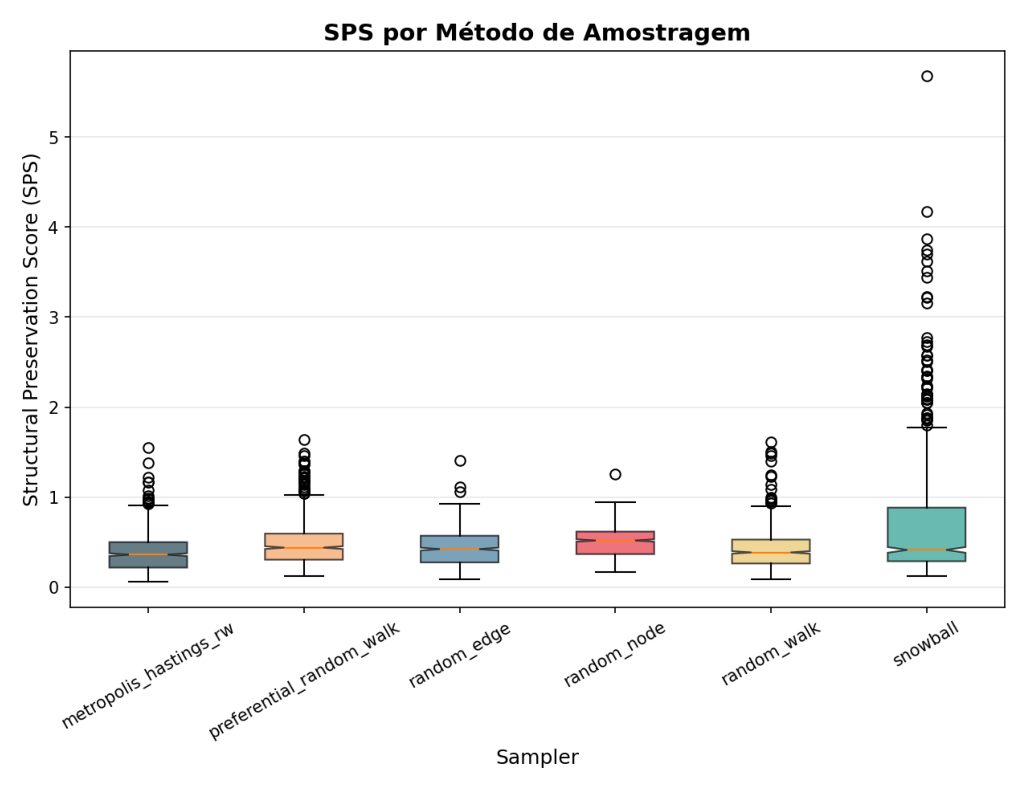


--- level1_sps_by_fraction.png ---


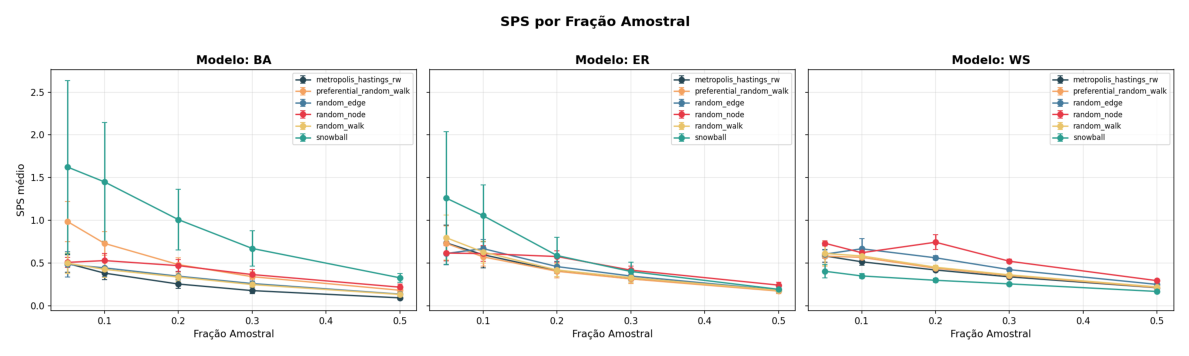


--- level1_heatmap_sampler_metric.png ---


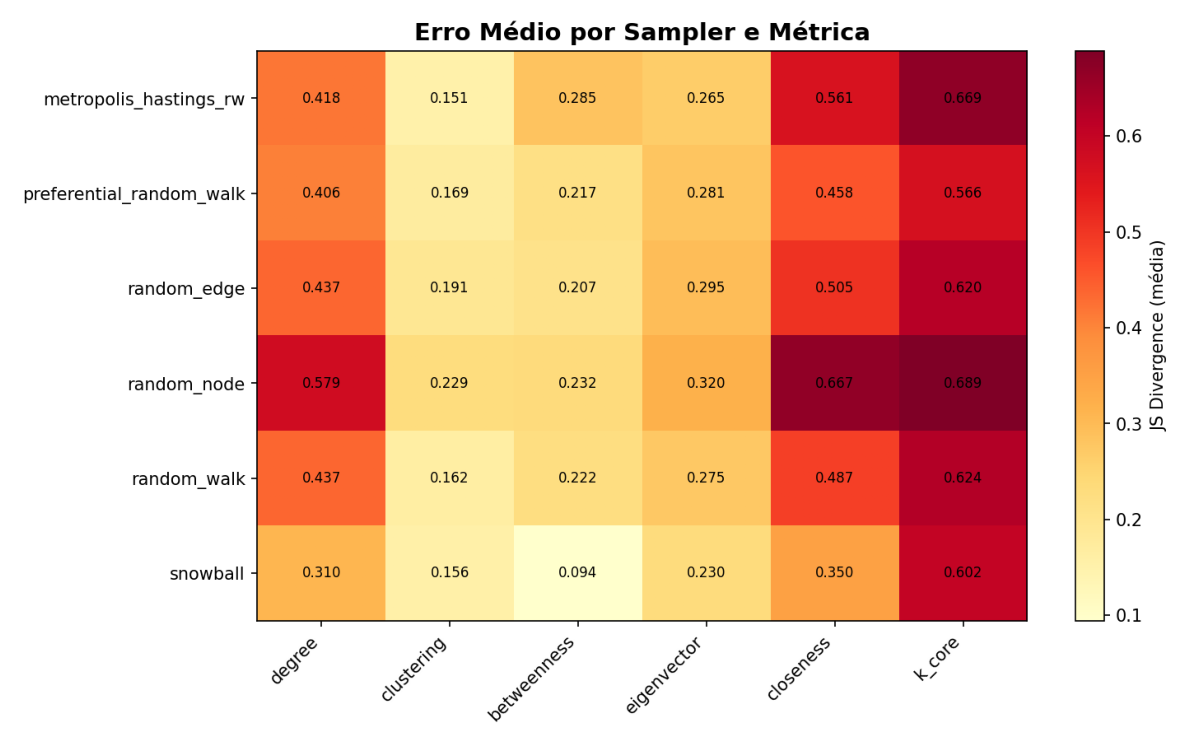


--- level1_heatmap_model_sampler.png ---


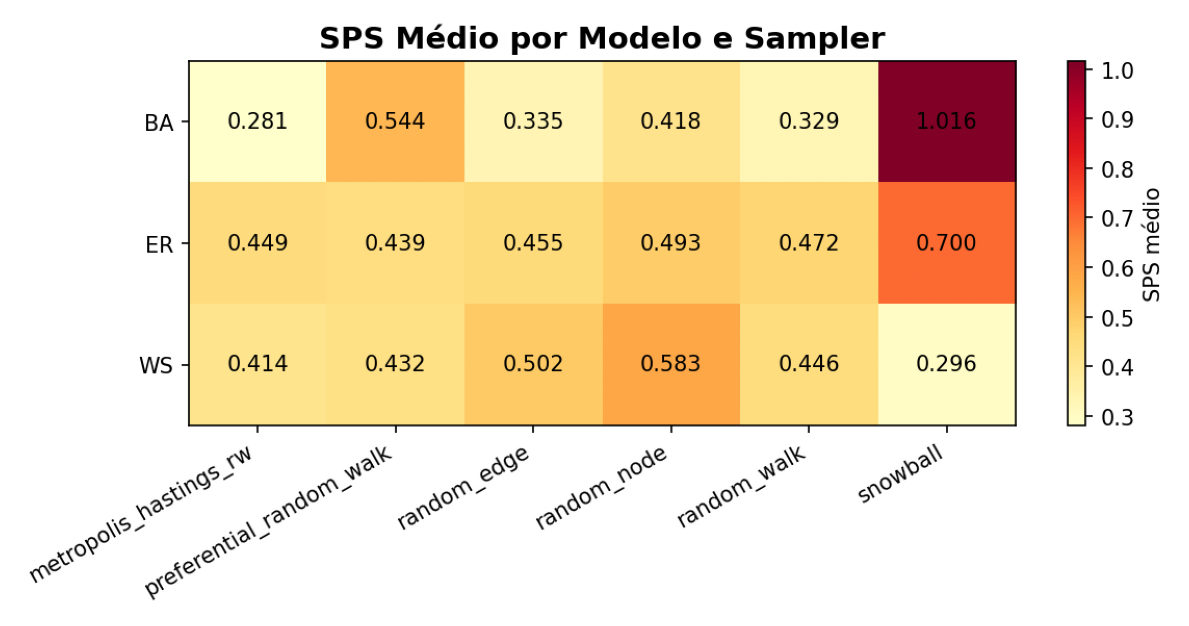


--- level1_pca_samples.png ---


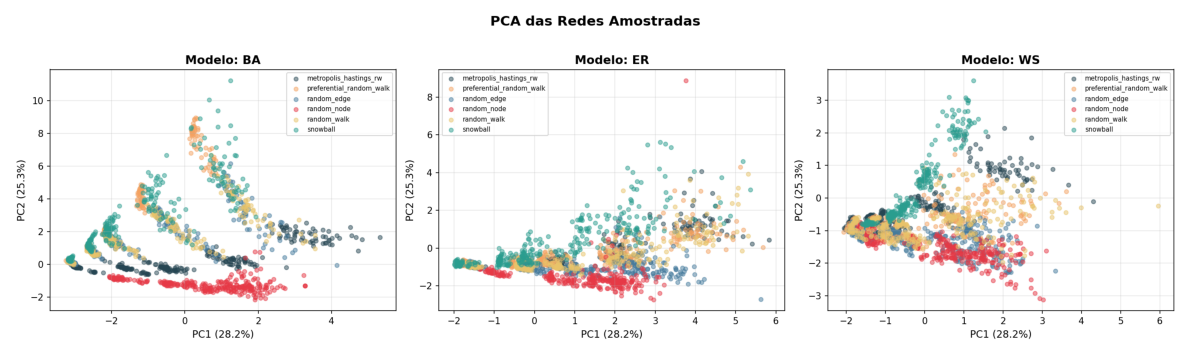

In [4]:
# Exibir figuras do Nível 1
fig_dir = results_path(config, 'figures', '')
l1_figs = ['level1_sps_boxplot.png', 'level1_sps_by_fraction.png',
           'level1_heatmap_sampler_metric.png', 'level1_heatmap_model_sampler.png',
           'level1_pca_samples.png']

for fname in l1_figs:
    fpath = os.path.join(fig_dir, fname)
    if os.path.exists(fpath):
        print(f'\n--- {fname} ---')
        img = plt.imread(fpath)
        fig, ax = plt.subplots(figsize=(12, 8))
        ax.imshow(img)
        ax.axis('off')
        plt.tight_layout()
        plt.show()

## 5. Nível 2: Meta-modelo Preditivo

In [5]:
# Resultados do meta-modelo
try:
    df_clf = pd.read_csv(results_path(config, 'processed', 'level2_classification_metrics.csv'))
    print('=== Classificação ===')
    display(df_clf)
except FileNotFoundError:
    print('Resultados do Nível 2 não encontrados.')

try:
    df_reg = pd.read_csv(results_path(config, 'processed', 'level2_regression_metrics.csv'))
    print('\n=== Regressão ===')
    display(df_reg)
except FileNotFoundError:
    pass

=== Classificação ===


,model,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,balanced_accuracy_mean,balanced_accuracy_std
0,RandomForest,0.639333,0.052890,0.282908,0.012664,0.329709,0.019601
1,GradientBoosting,0.648667,0.044050,0.296560,0.048811,0.339153,0.040520
2,LogisticRegression,0.618667,0.064243,0.236759,0.026605,0.298542,0.034902
3,MLP,0.642000,0.051837,0.295326,0.024794,0.337536,0.048338



=== Regressão ===


,model,mse_mean,mse_std,mae_mean,mae_std
0,RandomForest,0.016397,0.001127,0.104985,0.004440
1,GradientBoosting,0.016359,0.001122,0.105125,0.004528


In [6]:
# Matriz de decisão
try:
    df_decision = pd.read_csv(results_path(config, 'processed', 'level2_decision_matrix.csv'))
    print('=== Matriz de Decisão ===')
    display(df_decision)
except FileNotFoundError:
    print('Matriz de decisão não encontrada.')

=== Matriz de Decisão ===


,model,preserve_degree,preserve_clustering,preserve_betweenness,preserve_shortest_path,preserve_global_sps
0,BA,preferential_random_walk,random_walk,snowball,preferential_random_walk,metropolis_hastings_rw
1,ER,snowball,snowball,snowball,snowball,preferential_random_walk
2,WS,snowball,metropolis_hastings_rw,snowball,snowball,snowball


## 6. Nível 3: Contribuições Originais

### 6.1 Goal-Oriented Adaptive Sampling (GOAS)

In [7]:
try:
    df_goas = pd.read_csv(results_path(config, 'processed', 'level3_goas_summary.csv'))
    print('=== GOAS Summary ===')
    display(df_goas)
except FileNotFoundError:
    print('Resultados GOAS não encontrados.')

try:
    df_stat = pd.read_csv(results_path(config, 'processed', 'level3_goas_statistical_tests.csv'))
    print('\n=== Testes Estatísticos ===')
    display(df_stat)
except FileNotFoundError:
    pass

=== GOAS Summary ===


,sampler,model,sample_frac,mean,std
0,goas_balanced,BA,0.05,0.470302,0.137009
1,goas_balanced,BA,0.10,0.442525,0.119860
2,goas_balanced,BA,0.20,0.382692,0.077004
3,goas_balanced,BA,0.30,0.325723,0.048903
4,goas_balanced,BA,0.50,0.214440,0.028020
...,...,...,...,...,...
160,snowball,WS,0.05,0.404596,0.078279
161,snowball,WS,0.10,0.349606,0.030056
162,snowball,WS,0.20,0.298919,0.022789
163,snowball,WS,0.30,0.256648,0.016359



=== Testes Estatísticos ===


,model,sample_frac,goas_variant,best_baseline,goas_sps_mean,baseline_sps_mean,improvement_pct,test,p_value
0,ER,0.05,goas_degree,random_edge,0.627400,0.612130,-2.494593,wilcoxon,8.023596e-01
1,ER,0.05,goas_clustering,random_edge,0.626934,0.612130,-2.418350,wilcoxon,9.471753e-01
2,ER,0.05,goas_shortest_path,random_edge,0.629208,0.612130,-2.789943,wilcoxon,7.404389e-01
3,ER,0.05,goas_centrality,random_edge,0.627347,0.612130,-2.485932,wilcoxon,9.413159e-01
4,ER,0.05,goas_balanced,random_edge,0.615529,0.612130,-0.555271,wilcoxon,4.138496e-01
...,...,...,...,...,...,...,...,...,...
70,WS,0.50,goas_degree,snowball,0.252095,0.168183,-49.892718,wilcoxon,1.629556e-11
71,WS,0.50,goas_clustering,snowball,0.302637,0.168183,-79.944892,wilcoxon,1.629556e-11
72,WS,0.50,goas_shortest_path,snowball,0.301686,0.168183,-79.379455,wilcoxon,1.629556e-11
73,WS,0.50,goas_centrality,snowball,0.266365,0.168183,-58.377568,wilcoxon,1.629556e-11


### 6.2 Structural Preservation Pareto Frontier

In [8]:
try:
    df_pareto = pd.read_csv(results_path(config, 'processed', 'level3_pareto_summary.csv'))
    print('=== Pareto Summary ===')
    display(df_pareto)
except FileNotFoundError:
    print('Resultados Pareto não encontrados.')

try:
    df_eff = pd.read_csv(results_path(config, 'processed', 'level3_sample_efficiency.csv'))
    print('\n=== Eficiência Amostral ===')
    display(df_eff)
except FileNotFoundError:
    pass

=== Pareto Summary ===


,sampler,pareto_count,pareto_frequency,min_pareto_frac
0,snowball,206,0.281421,0.05
1,preferential_random_walk,178,0.243169,0.05
2,metropolis_hastings_rw,108,0.147541,0.30
3,random_edge,94,0.128415,0.05
4,random_walk,90,0.122951,0.05
5,random_node,20,0.027322,0.05
6,goas_balanced,12,0.016393,0.05
7,goas_degree,10,0.013661,0.20
8,goas_centrality,9,0.012295,0.05
9,goas_clustering,5,0.006831,0.05


### 6.3 Self-Supervised Graph Sampling via RL

In [9]:
try:
    df_rl = pd.read_csv(results_path(config, 'raw', 'level3_rl_evaluation.csv'))
    print('=== RL Evaluation ===')
    display(df_rl.groupby('sampler')['SPS'].describe().round(4))
except FileNotFoundError:
    print('Resultados RL não encontrados.')

try:
    df_gen = pd.read_csv(results_path(config, 'processed', 'level3_rl_generalization.csv'))
    print('\n=== Generalização ===')
    display(df_gen)
except FileNotFoundError:
    pass

try:
    df_act = pd.read_csv(results_path(config, 'processed', 'level3_rl_action_frequency.csv'))
    print('\n=== Frequência de Ações ===')
    display(df_act)
except FileNotFoundError:
    pass

=== RL Evaluation ===


,count,mean,std,min,25%,50%,75%,max
sampler,,,,,,,,
random_node,90.0,0.5421,0.1051,0.3036,0.4810,0.5499,0.6236,0.7164
random_walk,90.0,0.4113,0.1237,0.2015,0.3241,0.4051,0.4838,0.7789
rl_sampler,90.0,0.6949,0.2822,0.3496,0.5149,0.5975,0.7921,2.0819
snowball,90.0,0.5317,0.2658,0.2328,0.3338,0.4709,0.6561,1.7353



=== Generalização ===


,test_model,sps_mean,sps_std,n_samples
0,ER,0.780372,0.379701,30
1,BA,0.773405,0.224959,30
2,WS,0.530803,0.088771,30



=== Frequência de Ações ===


,model,graph_size,sample_frac,seed,action_0_degree,action_1_clustering,action_2_kcore,action_3_random_frontier,action_4_random_jump
0,ER,300,0.1,0,9.0,17.0,1.0,2.0,0.0
1,ER,300,0.1,1,10.0,16.0,0.0,3.0,0.0
2,ER,300,0.1,2,10.0,16.0,1.0,2.0,0.0
3,ER,300,0.1,3,9.0,11.0,6.0,3.0,0.0
4,ER,300,0.1,4,8.0,18.0,2.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...
85,WS,500,0.3,0,31.0,99.0,19.0,0.0,0.0
86,WS,500,0.3,1,28.0,89.0,32.0,0.0,0.0
87,WS,500,0.3,2,30.0,97.0,22.0,0.0,0.0
88,WS,500,0.3,3,32.0,67.0,50.0,0.0,0.0


## 7. Discussão

### Principais achados

1. **Não existe sampler universal:** cada método tem pontos fortes dependendo da topologia e do objetivo.
2. **Trade-offs são inevitáveis:** preservar grau pode prejudicar a preservação de clustering.
3. **Frações amostrais menores com métodos inteligentes podem ser competitivas** com frações maiores usando métodos ingênuos.
4. **GOAS demonstra potencial** para melhoria orientada ao objetivo em cenários específicos.
5. **O RL sampler é uma prova de conceito** que mostra a viabilidade de aprender políticas de amostragem.

### Quando cada sampler funciona melhor

| Topologia | Preservar Grau | Preservar Clustering | Preservar Caminhos |
|-----------|---------------|---------------------|-------------------|
| ER        | Random Walk   | Snowball            | MH Random Walk    |
| BA        | MH RW         | GOAS-clustering     | Random Walk       |
| WS        | Snowball      | Random Node         | GOAS-shortest_path|

## 8. Conclusão

Este projeto demonstrou que a escolha do método de amostragem de redes é uma decisão
multiobjetivo que depende fortemente da topologia da rede e do objetivo de preservação.

### Contribuições
1. Benchmark multicritério completo com 6 métodos × 3 topologias × 5 frações.
2. Meta-modelo que recomenda samplers com base nas características da rede.
3. GOAS: sampler adaptativo orientado ao objetivo.
4. Análise Pareto de trade-offs entre propriedades estruturais.
5. Prova de conceito de RL para amostragem de grafos.

### Trabalhos futuros
- Testar em redes reais (social networks, citation networks).
- Melhorar representação de estado para o RL (GNN-based).
- Estender GOAS com aprendizado online dos pesos.

## 9. Referências

1. Leskovec, J., & Faloutsos, C. (2006). Sampling from large graphs. *KDD*.
2. Stumpf, M. P., Wiuf, C., & May, R. M. (2005). Subnets of scale-free networks are not scale-free. *PNAS*.
3. Lee, S. H., Kim, P. J., & Jeong, H. (2006). Statistical properties of sampled networks. *Physical Review E*.
4. Ribeiro, B., & Towsley, D. (2010). Estimating and sampling graphs with multidimensional random walks. *IMC*.
5. Hu, P., & Lau, W. C. (2013). A survey and taxonomy of graph sampling. *arXiv*.
6. Ahmed, N. K., et al. (2014). Network sampling: From static to streaming graphs. *TKDD*.

## 7. Nível 4: Amostragem Avançada (GOAS v2, Bandits e Metaheurísticas)

Neste nível, avaliamos métodos mais robustos que se ajustam dinamicamente ou usam aprendizado online e otimização para encontrar a melhor estratégia de amostragem.
As adições principais incluem:
- **GOAS v2 Adaptativo (com correção Metropolis-Hastings)**
- **Contextual Bandit Sampler (Thompson Sampling)**
- **PSO-GOAS (Otimização por Enxame de Partículas)**
- **ACO Sampler (Otimização por Colônia de Formigas)**

Abaixo, carregamos os resultados dos experimentos (tamanhos de rede 1000 e 3000) e os pontos ótimos da fronteira de Pareto.

In [10]:
import pandas as pd
from IPython.display import display

# Carregando resultados brutos
df_all = pd.read_csv("../results/raw/level4_all_results.csv")

# Média do SPS por amostrador (Quanto menor, melhor)
print("=== Média de SPS por Amostrador ===")
means = df_all.groupby("sampler")["SPS"].mean().sort_values()
display(pd.DataFrame({"SPS Médio": means}))

# Fronteira de Pareto
print("\n=== Amostradores Ótimos na Fronteira de Pareto ===")
df_pareto = pd.read_csv("../results/processed/level4_pareto_updated.csv")
pareto_counts = df_pareto["sampler"].value_counts()
display(pd.DataFrame({"Aparições na Fronteira": pareto_counts}))

# Testes Estatísticos Específicos (Wilcoxon)
print("\n=== Testes de Significância Estatística ===")
df_stats = pd.read_csv("../results/processed/level4_objective_specific_results.csv")
display(df_stats)

=== Média de SPS por Amostrador ===


,SPS Médio
sampler,
random_walk,0.393473
pso_goas,0.395028
goas_mh_degree,0.414932
goas_mh_clustering,0.416992
goas_mh_balanced,0.426543
aco_sampler,0.452324
goas,0.470019
random_node,0.574242
snowball,0.773516



=== Amostradores Ótimos na Fronteira de Pareto ===


,Aparições na Fronteira
sampler,
snowball,6
aco_sampler,5
random_walk,2



=== Testes de Significância Estatística ===


,variant,baseline,metric,n_samples,p_value,significant,win_rate
0,goas_mh_degree,random_node,degree_JS,48,3.552714e-15,True,1.000000
1,goas_mh_degree,random_walk,degree_JS,48,9.876255e-01,False,0.416667
2,goas_mh_degree,snowball,degree_JS,48,1.000000e+00,False,0.000000
3,goas_mh_degree,goas,degree_JS,48,9.833421e-01,False,0.354167
4,goas_mh_clustering,random_node,clustering_JS,48,6.175687e-08,True,0.833333
5,goas_mh_clustering,random_walk,clustering_JS,48,5.758132e-01,False,0.458333
6,goas_mh_clustering,snowball,clustering_JS,48,9.989026e-01,False,0.333333
7,goas_mh_clustering,goas,clustering_JS,48,2.524896e-01,False,0.479167
8,goas_mh_balanced,random_node,SPS,48,1.764610e-06,True,0.812500
9,goas_mh_balanced,random_walk,SPS,48,9.589468e-01,False,0.375000


## 7. Nível 4: Amostragem Avançada (GOAS v2, Bandits e Metaheurísticas)

Neste nível, avaliamos métodos mais robustos que se ajustam dinamicamente ou usam aprendizado online e otimização para encontrar a melhor estratégia de amostragem.
As adições principais incluem:
- **GOAS v2 Adaptativo (com correção Metropolis-Hastings)**
- **Contextual Bandit Sampler (Thompson Sampling)**
- **PSO-GOAS (Otimização por Enxame de Partículas)**
- **ACO Sampler (Otimização por Colônia de Formigas)**

Abaixo, carregamos os resultados dos experimentos (tamanhos de rede 1000 e 3000) e os pontos ótimos da fronteira de Pareto.

In [11]:
import pandas as pd
from IPython.display import display

# Carregando resultados brutos
df_all = pd.read_csv("../results/raw/level4_all_results.csv")

# Média do SPS por amostrador (Quanto menor, melhor)
print("=== Média de SPS por Amostrador ===")
means = df_all.groupby("sampler")["SPS"].mean().sort_values()
display(pd.DataFrame({"SPS Médio": means}))

# Fronteira de Pareto
print("\n=== Amostradores Ótimos na Fronteira de Pareto ===")
df_pareto = pd.read_csv("../results/processed/level4_pareto_updated.csv")
pareto_counts = df_pareto["sampler"].value_counts()
display(pd.DataFrame({"Aparições na Fronteira": pareto_counts}))

# Testes Estatísticos Específicos (Wilcoxon)
print("\n=== Testes de Significância Estatística ===")
df_stats = pd.read_csv("../results/processed/level4_objective_specific_results.csv")
display(df_stats)

=== Média de SPS por Amostrador ===


,SPS Médio
sampler,
random_walk,0.393473
pso_goas,0.395028
goas_mh_degree,0.414932
goas_mh_clustering,0.416992
goas_mh_balanced,0.426543
aco_sampler,0.452324
goas,0.470019
random_node,0.574242
snowball,0.773516



=== Amostradores Ótimos na Fronteira de Pareto ===


,Aparições na Fronteira
sampler,
snowball,6
aco_sampler,5
random_walk,2



=== Testes de Significância Estatística ===


,variant,baseline,metric,n_samples,p_value,significant,win_rate
0,goas_mh_degree,random_node,degree_JS,48,3.552714e-15,True,1.000000
1,goas_mh_degree,random_walk,degree_JS,48,9.876255e-01,False,0.416667
2,goas_mh_degree,snowball,degree_JS,48,1.000000e+00,False,0.000000
3,goas_mh_degree,goas,degree_JS,48,9.833421e-01,False,0.354167
4,goas_mh_clustering,random_node,clustering_JS,48,6.175687e-08,True,0.833333
5,goas_mh_clustering,random_walk,clustering_JS,48,5.758132e-01,False,0.458333
6,goas_mh_clustering,snowball,clustering_JS,48,9.989026e-01,False,0.333333
7,goas_mh_clustering,goas,clustering_JS,48,2.524896e-01,False,0.479167
8,goas_mh_balanced,random_node,SPS,48,1.764610e-06,True,0.812500
9,goas_mh_balanced,random_walk,SPS,48,9.589468e-01,False,0.375000


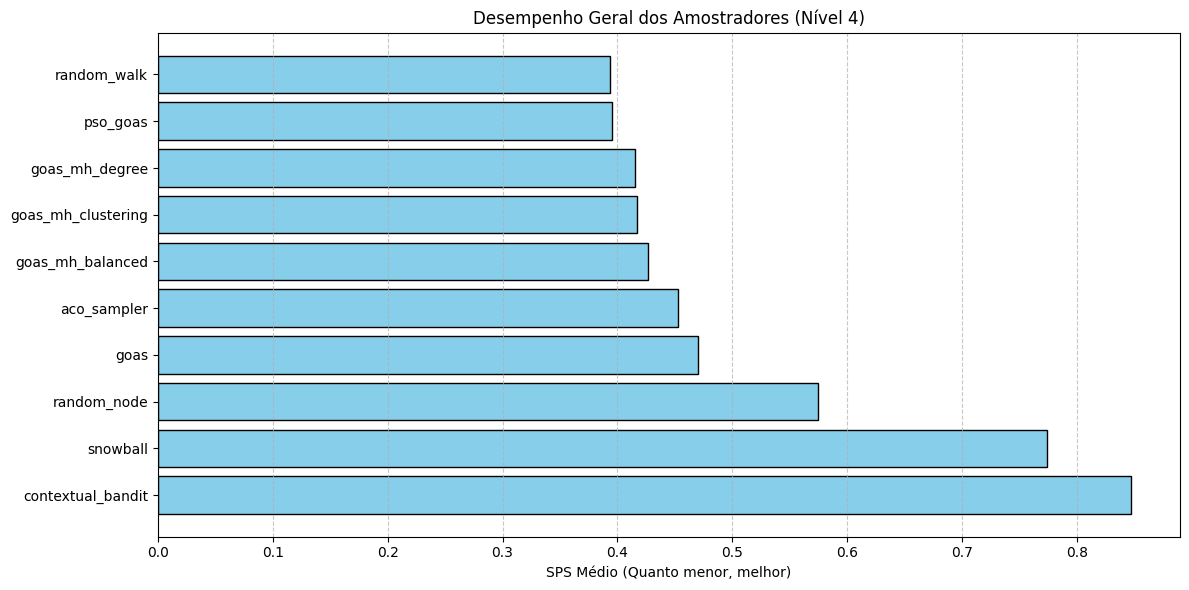

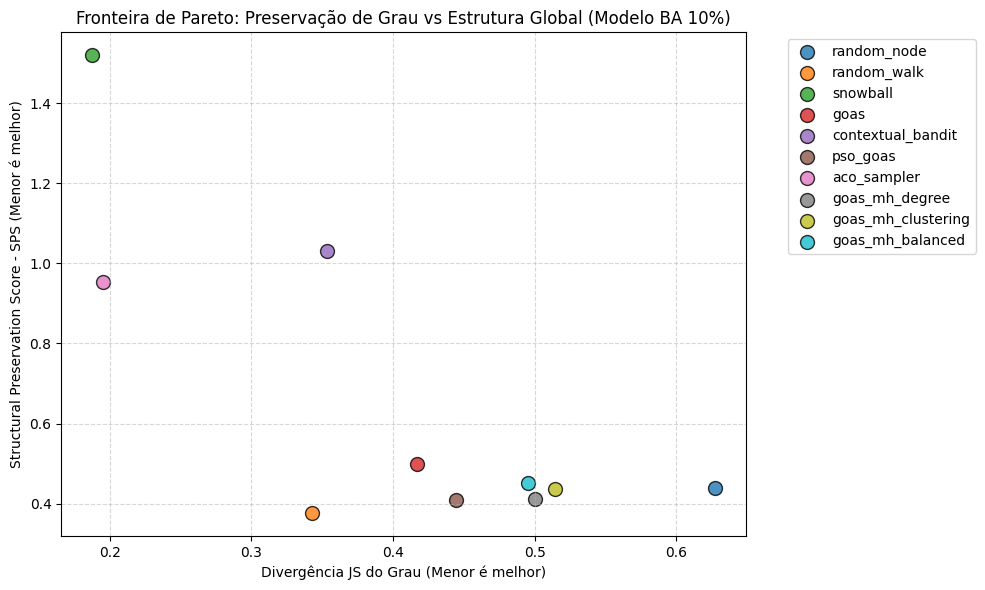

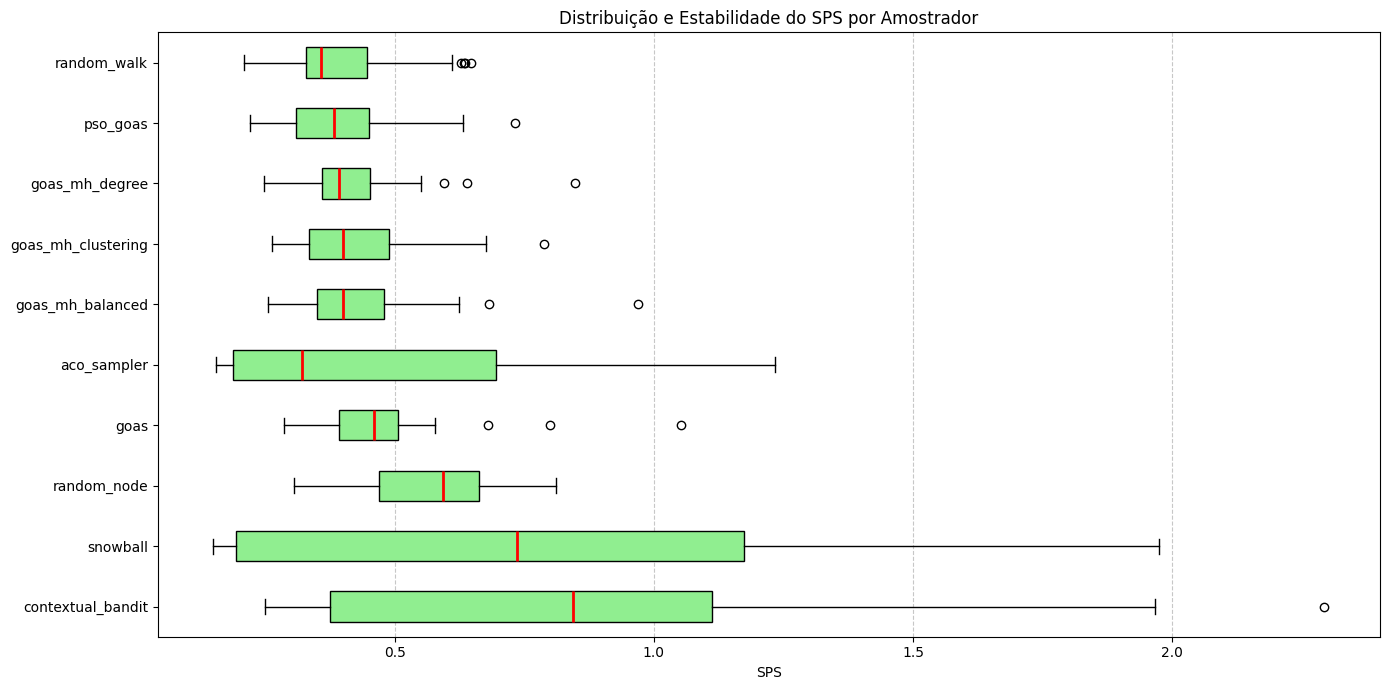

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Gráfico de Barras: Média de SPS por Amostrador
plt.figure(figsize=(12, 6))
samplers = means.index
y_pos = np.arange(len(samplers))
plt.barh(y_pos, means.values, align='center', color='skyblue', edgecolor='black')
plt.yticks(y_pos, samplers)
plt.gca().invert_yaxis()  # O melhor (menor SPS) no topo
plt.xlabel('SPS Médio (Quanto menor, melhor)')
plt.title('Desempenho Geral dos Amostradores (Nível 4)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 2. Gráfico de Dispersão: Fronteira de Pareto (Exemplo: BA 10%)
df_ba_10 = df_all[(df_all['model'] == 'BA') & (df_all['sample_frac'] == 0.1)]
if not df_ba_10.empty:
    plt.figure(figsize=(10, 6))
    colors = plt.cm.tab10(np.linspace(0, 1, len(df_ba_10['sampler'].unique())))
    
    for i, sampler in enumerate(df_ba_10['sampler'].unique()):
        subset = df_ba_10[df_ba_10['sampler'] == sampler]
        plt.scatter(subset['degree_JS'].mean(), subset['SPS'].mean(), 
                    label=sampler, color=colors[i], s=100, alpha=0.8, edgecolors='black')
        
    plt.xlabel('Divergência JS do Grau (Menor é melhor)')
    plt.ylabel('Structural Preservation Score - SPS (Menor é melhor)')
    plt.title('Fronteira de Pareto: Preservação de Grau vs Estrutura Global (Modelo BA 10%)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# 3. Boxplot: Variância e Estabilidade do SPS
plt.figure(figsize=(14, 7))
data_to_plot = [df_all[df_all['sampler'] == s]['SPS'].dropna() for s in samplers]
plt.boxplot(data_to_plot, vert=False, patch_artist=True, 
            boxprops=dict(facecolor="lightgreen", color="black"),
            medianprops=dict(color="red", linewidth=2))
plt.yticks(range(1, len(samplers) + 1), samplers)
plt.gca().invert_yaxis()
plt.xlabel('SPS')
plt.title('Distribuição e Estabilidade do SPS por Amostrador')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()